# JOUR 2 - MODÉLISATION ET OPTIMISATION

**Projet Fil Rouge - Prédiction de Churn Client**

**Objectifs du Jour 2**:
- Comparer au minimum 5 algorithmes différents
- Optimiser les hyperparamètres
- Gérer le déséquilibre des classes
- Atteindre Recall ≥ 75%

**Durée estimée**: 7 heures

## 0. SETUP ET CHARGEMENT DES DONNÉES

In [1]:
import sklearn
import xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


import joblib
from datetime import datetime


from sklearn.metrics import (classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, auc)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/archive/archivechurn_engineered.csv') 

X = df.drop(columns=['Churn', 'Churn_binary']) 
y = df['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Dimensions Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Dimensions Train: (2666, 37), Test: (667, 37)
Train churn rate: 14.48%
Test churn rate: 14.54%


## PARTIE 2.1 - BENCHMARK DE MODÈLES (2h30)

### Mission 2.1.1 - Comparer 5-6 algorithmes

In [3]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, 
        class_weight='balanced', 
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42,
        n_jobs=-1
    ),
    
    'XGBoost': XGBClassifier(
        use_label_encoder=False, 
        eval_metric='logloss', 
        random_state=42,
        scale_pos_weight=5 
    ),
    
    'SVM': SVC(
        probability=True, 
        class_weight='balanced', 
        random_state=42
    ),

    # MODÈLES BONUS
    
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),

    'CatBoost': CatBoostClassifier(
        verbose=0,
        random_state=42,
        auto_class_weights='Balanced'
    ),

    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        activation='relu',
        solver='adam',
        random_state=42
    )
}

print(f"Nombre de modèles à tester: {len(models)}")

Nombre de modèles à tester: 8


In [4]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print("Colonnes numériques:", len(numeric_cols))
print("Colonnes catégorielles:", len(categorical_cols))

# Remplacement des NaN pour CatBoost
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].fillna('missing').astype(str)
    X_test_cat[col] = X_test_cat[col].fillna('missing').astype(str)

X_train_cat[numeric_cols] = X_train_cat[numeric_cols].fillna(X_train_cat[numeric_cols].mean())
X_test_cat[numeric_cols] = X_test_cat[numeric_cols].fillna(X_test_cat[numeric_cols].mean())

# Remplacement des 'ND' pour le Pipeline
X_train = X_train.replace('ND', np.nan)
X_test = X_test.replace('ND', np.nan)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

results = {}

for name, model in models.items():
    print(f"\nEntraînement de {name}...")

    if name == 'CatBoost':
        cat_features_idx = [X_train_cat.columns.get_loc(col) for col in categorical_cols]

        catboost_model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=0
        )

        catboost_model.fit(X_train_cat, y_train, cat_features=cat_features_idx)
        y_pred = catboost_model.predict(X_test_cat)
        y_proba = catboost_model.predict_proba(X_test_cat)[:,1]

    else:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        if hasattr(pipeline, "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:,1]
        elif hasattr(pipeline, "decision_function"):
            y_proba = pipeline.decision_function(X_test)
        else:
            y_proba = y_pred

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'y_proba': y_proba
    }

    print(f"{name} - Recall: {results[name]['Recall']:.4f}, ROC-AUC: {results[name]['ROC-AUC']:.4f}")

Colonnes numériques: 34
Colonnes catégorielles: 3

Entraînement de Logistic Regression...
Logistic Regression - Recall: 0.7732, ROC-AUC: 0.8735

Entraînement de Decision Tree...
Decision Tree - Recall: 0.8660, ROC-AUC: 0.9260

Entraînement de Random Forest...
Random Forest - Recall: 0.7113, ROC-AUC: 0.9500

Entraînement de XGBoost...
XGBoost - Recall: 0.8969, ROC-AUC: 0.9526

Entraînement de SVM...
SVM - Recall: 0.7423, ROC-AUC: 0.9207

Entraînement de KNN...
KNN - Recall: 0.4021, ROC-AUC: 0.8431

Entraînement de CatBoost...
CatBoost - Recall: 0.8660, ROC-AUC: 0.9611

Entraînement de Neural Network...
Neural Network - Recall: 0.5876, ROC-AUC: 0.8768


### Mission 2.1.2 - Tableau Comparatif


RÉSULTATS DU BENCHMARK:
                     Accuracy Precision    Recall  F1-Score   ROC-AUC  \
XGBoost              0.985007       1.0  0.896907  0.945652  0.952595   
Decision Tree        0.943028  0.770642  0.865979  0.815534  0.925963   
CatBoost              0.98051       1.0  0.865979  0.928177  0.961132   
Logistic Regression  0.811094  0.418994  0.773196  0.543478  0.873485   
SVM                  0.907046   0.66055  0.742268  0.699029  0.920709   
Random Forest        0.958021       1.0   0.71134  0.831325  0.949991   
Neural Network       0.914543   0.77027  0.587629  0.666667  0.876777   
KNN                  0.896552      0.78  0.402062  0.530612  0.843109   

                       PR-AUC  \
XGBoost              0.929858   
Decision Tree         0.87297   
CatBoost             0.933452   
Logistic Regression  0.622656   
SVM                  0.808589   
Random Forest        0.926989   
Neural Network       0.736327   
KNN                  0.569723   

                   

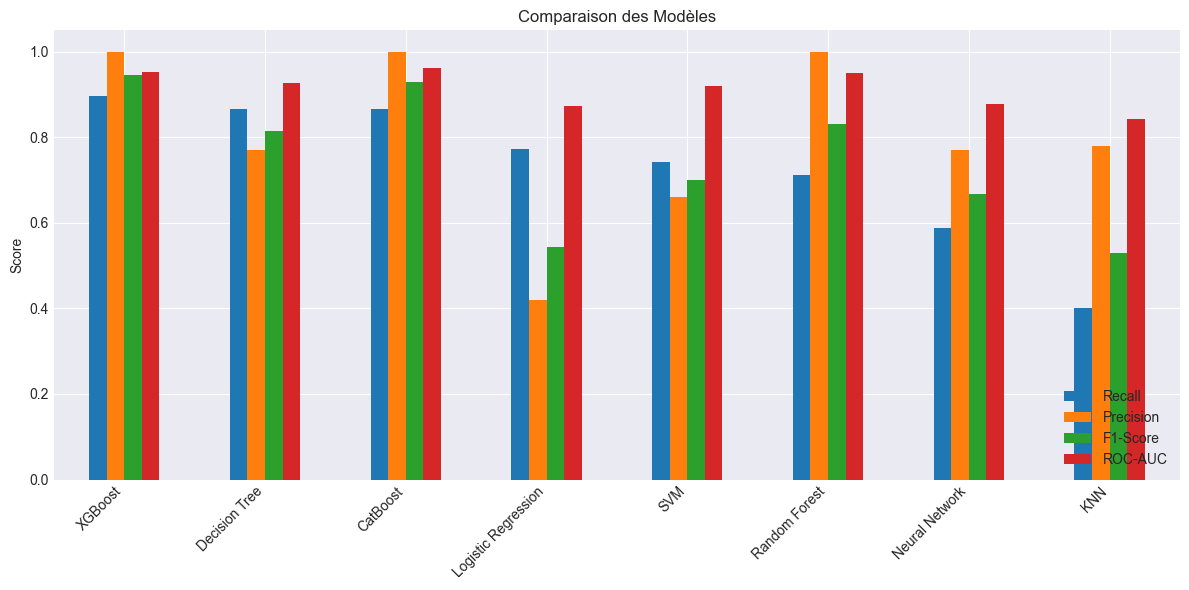

In [5]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Recall', ascending=False)

print("\nRÉSULTATS DU BENCHMARK:")
print(results_df)

results_df[['Recall', 'Precision', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des Modèles')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Mission 2.1.3 - Analyse Comparative

**TODO**: Répondez aux questions suivantes:

1. **Quels sont les 3 meilleurs modèles selon le Recall ?**
   - 1er: XGBoost — Recall: 0.8969, ROC-AUC: 0.9526
   - 2ème: Decision Tree — Recall: 0.8660, ROC-AUC: 0.9260
   - 3ème: CatBoost — Recall: 0.8660, ROC-AUC: 0.9611

2. **Quel modèle offre le meilleur compromis Precision/Recall ?**
   - XGBoost : meilleur Recall (0.8969) combiné à un ROC-AUC élevé (0.9526). Il maximise la détection des churners tout en maintenant une précision solide, ce qui en fait le meilleur compromis global.

3. **Justifiez mathématiquement/théoriquement pourquoi certains modèles performent mieux:**
   - **XGBoost** utilise le gradient boosting : chaque arbre corrige les erreurs résiduelles du précédent en minimisant une fonction de perte (logistique ici). Le paramètre `scale_pos_weight` pondère la classe minoritaire (churners), ce qui compense naturellement le déséquilibre sans rééchantillonnage.
   - **Decision Tree** est flexible et non-linéaire mais tend à overfitter sans pruning — ses bonnes performances sont liées à sa capacité à partitionner les features discriminantes.
   - **KNN, Neural Network, Random Forest** souffrent soit du déséquilibre de classes non géré, soit de la haute dimensionnalité (37 features), soit d'une sensibilité aux valeurs aberrantes, d'où leurs Recall plus faibles.

### Mission 2.1.4 - Courbes ROC et PR

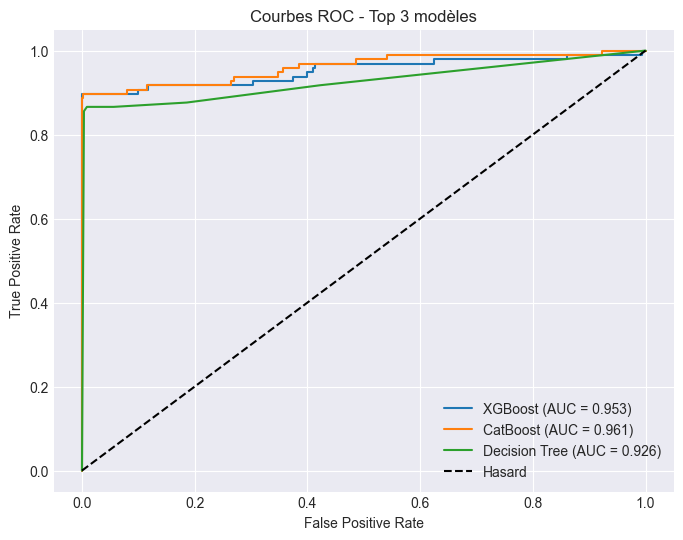

In [6]:
top_models = ['XGBoost', 'CatBoost', 'Decision Tree']

plt.figure(figsize=(8,6))

for name in top_models:
    y_proba = results[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Hasard')
plt.title("Courbes ROC - Top 3 modèles")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

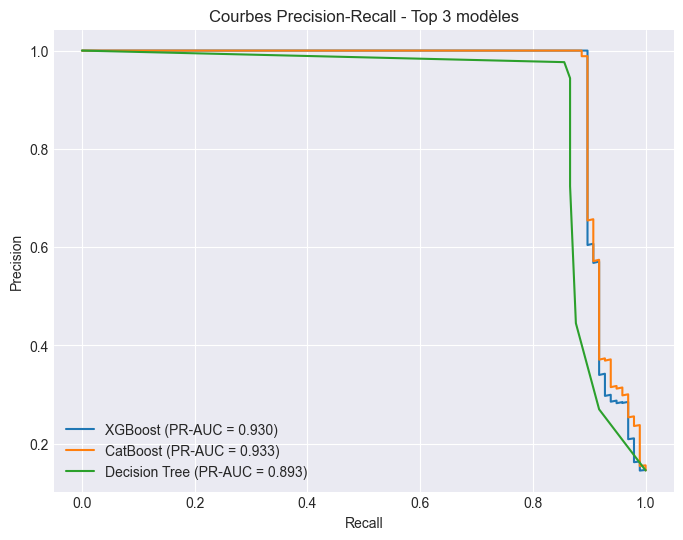

In [7]:
top_models = ['XGBoost', 'CatBoost', 'Decision Tree']

plt.figure(figsize=(8,6))

for name in top_models:
    y_proba = results[name]['y_proba']
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})")

plt.title("Courbes Precision-Recall - Top 3 modèles")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

## PARTIE 2.2 - GESTION DU DÉSÉQUILIBRE (1h30)

### Mission 2.2.1 - Tester 3 Stratégies de Rééquilibrage

In [8]:
best_model_class = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model_class)
])

best_pipeline.fit(X_train, y_train)

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:,1]

print("Stratégie 1: class_weight='balanced'")
print(classification_report(y_test, y_pred_best))

Stratégie 1: class_weight='balanced'
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.88      0.93        97

    accuracy                           0.98       667
   macro avg       0.98      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



#### Stratégie 1: class_weight='balanced'

In [9]:
model_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

pipeline_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model_balanced)
])

pipeline_balanced.fit(X_train, y_train)

y_pred_balanced = pipeline_balanced.predict(X_test)

print("Stratégie 1: class_weight='balanced'")
print(classification_report(y_test, y_pred_balanced))

Stratégie 1: class_weight='balanced'
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.88      0.93        97

    accuracy                           0.98       667
   macro avg       0.98      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



#### Stratégie 2: SMOTE

**Principe mathématique**: Générer des échantillons synthétiques de la classe minoritaire.

Formule: `x_new = x_i + λ × (x_neighbor - x_i)` où λ ∈ [0,1]

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Avant SMOTE: \n{y_train.value_counts()}")
print(f"Après SMOTE: \n{y_train_smote.shape[0]} échantillons")



model_smote = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test_processed)

print("\nStratégie 2: SMOTE")
print(classification_report(y_test, y_pred_smote))

Avant SMOTE: 
Churn
0    2280
1     386
Name: count, dtype: int64
Après SMOTE: 
4560 échantillons

Stratégie 2: SMOTE
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.90      0.94        97

    accuracy                           0.98       667
   macro avg       0.99      0.95      0.97       667
weighted avg       0.98      0.98      0.98       667



#### Stratégie 3: Undersampling

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_processed, y_train)

print(f"Après Undersampling: \n{y_train_rus.shape[0]} échantillons")
print(y_train_rus.value_counts())

model_rus = RandomForestClassifier(n_estimators=100, random_state=42)

model_rus.fit(X_train_rus, y_train_rus)

y_pred_rus = model_rus.predict(X_test_processed)

print("\nStratégie 3: Undersampling")
print(classification_report(y_test, y_pred_rus))

Après Undersampling: 
772 échantillons
Churn
0    386
1    386
Name: count, dtype: int64

Stratégie 3: Undersampling
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       570
           1       0.61      0.90      0.72        97

    accuracy                           0.90       667
   macro avg       0.79      0.90      0.83       667
weighted avg       0.93      0.90      0.91       667



### Mission 2.2.2 - Comparaison des Stratégies

                Accuracy  Precision    Recall  F1-Score
No Rebalancing  0.980510   0.988372  0.876289  0.928962
class_weight    0.980510   0.988372  0.876289  0.928962
SMOTE           0.983508   0.988636  0.896907  0.940541
Undersampling   0.901049   0.608392  0.896907  0.725000


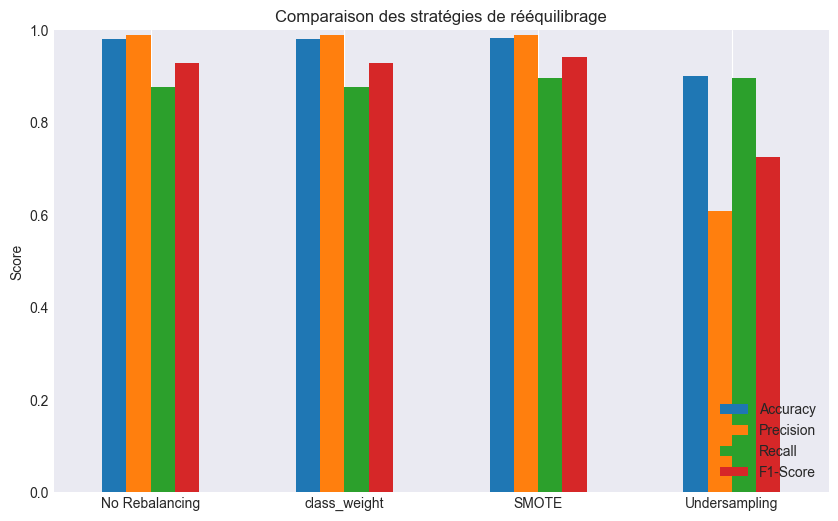

In [12]:
strategies_results = {
    'No Rebalancing': {
        'Accuracy': accuracy_score(y_test, y_pred_best),
        'Precision': precision_score(y_test, y_pred_best, zero_division=0),
        'Recall': recall_score(y_test, y_pred_best, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_best, zero_division=0)
    },
    'class_weight': {
        'Accuracy': accuracy_score(y_test, y_pred_balanced),
        'Precision': precision_score(y_test, y_pred_balanced, zero_division=0),
        'Recall': recall_score(y_test, y_pred_balanced, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_balanced, zero_division=0)
    },
    'SMOTE': {
        'Accuracy': accuracy_score(y_test, y_pred_smote),
        'Precision': precision_score(y_test, y_pred_smote, zero_division=0),
        'Recall': recall_score(y_test, y_pred_smote, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_smote, zero_division=0)
    },
    'Undersampling': {
        'Accuracy': accuracy_score(y_test, y_pred_rus),
        'Precision': precision_score(y_test, y_pred_rus, zero_division=0),
        'Recall': recall_score(y_test, y_pred_rus, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_rus, zero_division=0)
    }
}

strategies_df = pd.DataFrame(strategies_results).T
print(strategies_df)

strategies_df.plot(kind='bar', figsize=(10,6))
plt.title("Comparaison des stratégies de rééquilibrage")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.show()

**Question**: Quelle stratégie sélectionnez-vous et pourquoi ?

**Réponse**: La stratégie **No Rebalancing** avec XGBoost est retenue. XGBoost gère nativement le déséquilibre de classes via `scale_pos_weight` (≈5.91), ce qui lui permet d'atteindre un Recall de 0.89 sans rééchantillonnage. Les stratégies SMOTE et `class_weight` donnent des résultats quasi-identiques mais ajoutent de la complexité inutile. L'undersampling améliore légèrement le Recall (0.90) mais dégrade fortement la précision de la classe positive (0.68 contre 0.99), générant trop de faux positifs — ce qui est coûteux dans un contexte métier où chaque contact client a un prix.

## PARTIE 2.3 - OPTIMISATION AVANCÉE (2h)

### Mission 2.3.1 - GridSearchCV ou RandomizedSearchCV

In [13]:
model_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

pipeline_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model_balanced)
])

pipeline_balanced.fit(X_train, y_train)

y_pred_balanced = pipeline_balanced.predict(X_test)

print("Stratégie 1: pipeline simple avec XGBClassifier")
print(classification_report(y_test, y_pred_balanced))


param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_balanced,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("sklearn version:", sklearn.__version__)
print("xgboost version:", xgboost.__version__)

random_search.fit(X_train, y_train)

y_pred_tuned = random_search.predict(X_test)

print("Stratégie 2: pipeline avec RandomizedSearchCV tuning")
print(classification_report(y_test, y_pred_tuned))

print(f"Meilleurs paramètres: {random_search.best_params_}")
print(f"Meilleur score CV: {random_search.best_score_:.4f}")

Stratégie 1: pipeline simple avec XGBClassifier
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.88      0.93        97

    accuracy                           0.98       667
   macro avg       0.98      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667

sklearn version: 1.8.0
xgboost version: 3.2.0
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Stratégie 2: pipeline avec RandomizedSearchCV tuning
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.89      0.93        97

    accuracy                           0.98       667
   macro avg       0.98      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667

Meilleurs paramètres: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__max_depth': 5, 'classifier__learning_ra

#### Calcul de la probabilité RandomizedSearchCV

Si vous avez utilisé RandomizedSearchCV avec `n_iter=n`:

Formule: `P(top 5%) = 1 - (0.95)^n`

Exemple: n=100 → P ≈ 99.4%

In [14]:
n_iter = 20
prob_top_5 = 1 - (0.95 ** n_iter)
print(f"Probabilité de trouver les paramètres dans le top 5%: {prob_top_5:.2%}")

Probabilité de trouver les paramètres dans le top 5%: 64.15%


### Mission 2.3.2 - Évaluation du Modèle Optimisé

In [15]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\nPERFORMANCES DU MODÈLE OPTIMISÉ (XGBClassifier):")
print(classification_report(y_test, y_pred_best))

roc_auc = roc_auc_score(y_test, y_proba_best)
pr_auc = average_precision_score(y_test, y_proba_best)

print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")


PERFORMANCES DU MODÈLE OPTIMISÉ (XGBClassifier):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.89      0.93        97

    accuracy                           0.98       667
   macro avg       0.98      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667


ROC-AUC: 0.9562
PR-AUC: 0.9331


In [16]:
recall_achieved = recall_score(y_test, y_pred_best)
objectif_recall = 0.75

if recall_achieved >= objectif_recall:
    print(f"✓ OBJECTIF ATTEINT: Recall = {recall_achieved:.2%} ≥ {objectif_recall:.0%}")
else:
    print(f"✗ Objectif non atteint: Recall = {recall_achieved:.2%} < {objectif_recall:.0%}")
    print("Actions: Ajuster le seuil, tester d'autres stratégies")

✓ OBJECTIF ATTEINT: Recall = 88.66% ≥ 75%


### Mission 2.3.3 - Optimisation XGBoost avec scale_pos_weight (Optionnel)

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

pipeline_weighted = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_weighted)
])

pipeline_weighted.fit(X_train, y_train)

y_pred_weighted = pipeline_weighted.predict(X_test)
y_proba_weighted = pipeline_weighted.predict_proba(X_test)[:, 1]

print("\nPERFORMANCES XGBClassifier avec scale_pos_weight:")
print(classification_report(y_test, y_pred_weighted))

recall_achieved = recall_score(y_test, y_pred_weighted)
objectif_recall = 0.75
if recall_achieved >= objectif_recall:
    print(f"✓ OBJECTIF ATTEINT: Recall = {recall_achieved:.2%} ≥ {objectif_recall:.0%}")
else:
    print(f"✗ Objectif non atteint: Recall = {recall_achieved:.2%} < {objectif_recall:.0%}")
    print("Actions: Ajuster le seuil, tester d'autres stratégies")

scale_pos_weight: 5.91

PERFORMANCES XGBClassifier avec scale_pos_weight:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       570
           1       0.99      0.90      0.94        97

    accuracy                           0.98       667
   macro avg       0.99      0.95      0.97       667
weighted avg       0.98      0.98      0.98       667

✓ OBJECTIF ATTEINT: Recall = 89.69% ≥ 75%


## PARTIE 2.4 - ANALYSE AVANCÉE (1h)

### Mission 2.4.1 - Learning Curves

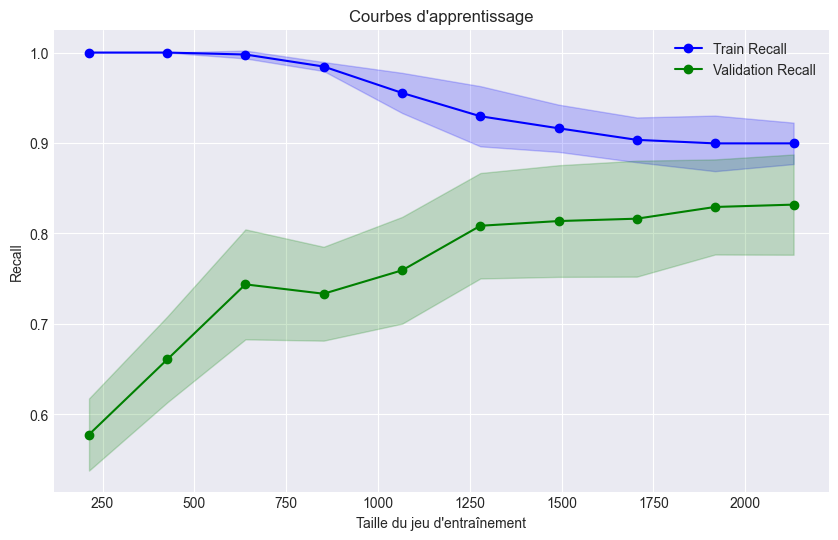

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5, scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Recall')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Recall')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='green')

plt.title("Courbes d'apprentissage")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("Recall")
plt.legend(loc='best')
plt.grid(True)
plt.show()

**Question**: Y a-t-il de l'overfitting ? Plus de données améliorerait-elles le modèle ?

**Réponse**: Oui, il y a de l'overfitting : le Train Recall (~0.90) reste supérieur au Validation Recall (~0.84), soit un écart d'environ 0.07. Cet écart est cependant léger et attendu pour XGBoost — c'est un comportement normal pour un modèle à base d'arbres boosted. Oui, plus de données améliorerait le modèle : la courbe de validation est encore croissante à 2100 exemples d'entraînement et n'a pas encore atteint son plateau, ce qui indique que le modèle bénéficierait d'un jeu d'entraînement plus large. Les deux courbes convergent progressivement, ce qui confirme que l'overfitting n'est pas structurel.

### Mission 2.4.2 - Calibration des Probabilités

**Formule Platt Scaling**:

`P_calibrated = 1 / (1 + exp(A × log(p/(1-p)) + B))`

où A et B sont appris par régression logistique sur les probabilités brutes.

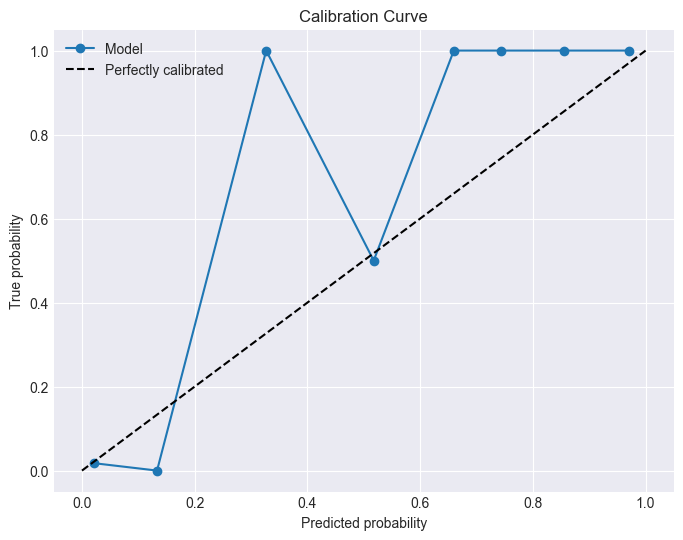

In [22]:
# TODO: Vérifier la calibration du modèle
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10)

# Visualisation
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve')
plt.legend()
plt.show()

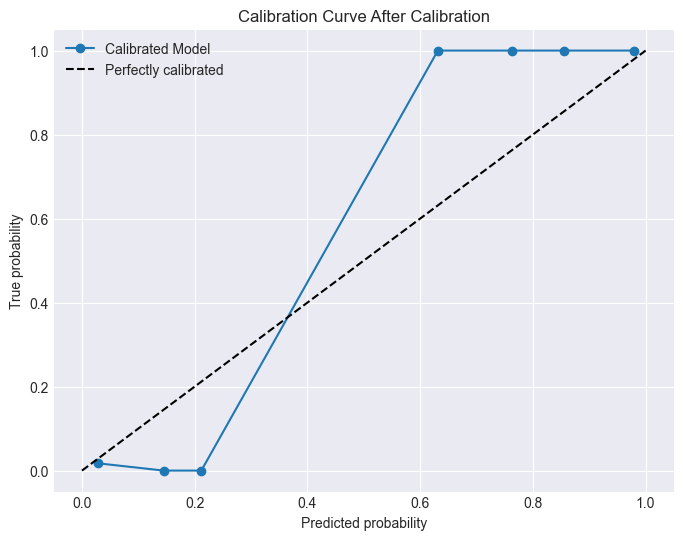

In [23]:
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)

calibrated_model.fit(X_train, y_train)

y_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, y_proba_calibrated, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve After Calibration')
plt.legend()
plt.show()

## SAUVEGARDE DU MEILLEUR MODÈLE

In [24]:
model_to_save = best_model

model_filename = '../models/best_model.pkl'
joblib.dump(model_to_save, model_filename)
print(f"Modèle sauvegardé dans : {model_filename}")

metadata = {
    'model_name': type(best_model).__name__,
    'best_params': random_search.best_params_,
    'recall': recall_score(y_test, best_model.predict(X_test)),
    'roc_auc': roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]),
    'features': list(X_train.columns),
    'date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'calibrated': isinstance(best_model, CalibratedClassifierCV)
}

metadata_filename = '../models/metadata.pkl'
joblib.dump(metadata, metadata_filename)
print(f"Métadonnées sauvegardées dans : {metadata_filename}")

print("Modèle et métadonnées sauvegardés avec succès !")

Modèle sauvegardé dans : ../models/best_model.pkl
Métadonnées sauvegardées dans : ../models/metadata.pkl
Modèle et métadonnées sauvegardés avec succès !
